# Submission Pertama: Menyelesaikan Permasalahan Human Resources

- Nama: Arisyi Said Tanjung
- Email: arisyisaid14@gmail.com
- Id Dicoding:arisyisaid

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


### Menyiapkan data yang akan digunakan

In [2]:
df = pd.read_csv("/content/employee_data.csv")
print('employee_data.csv shape: ', df.shape)

df.head()

employee_data.csv shape:  (1470, 35)


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [4]:
df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.isnull().sum()

,0
EmployeeId,0
Age,0
Attrition,412
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


/tmp/ipykernel_44846/868691066.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)


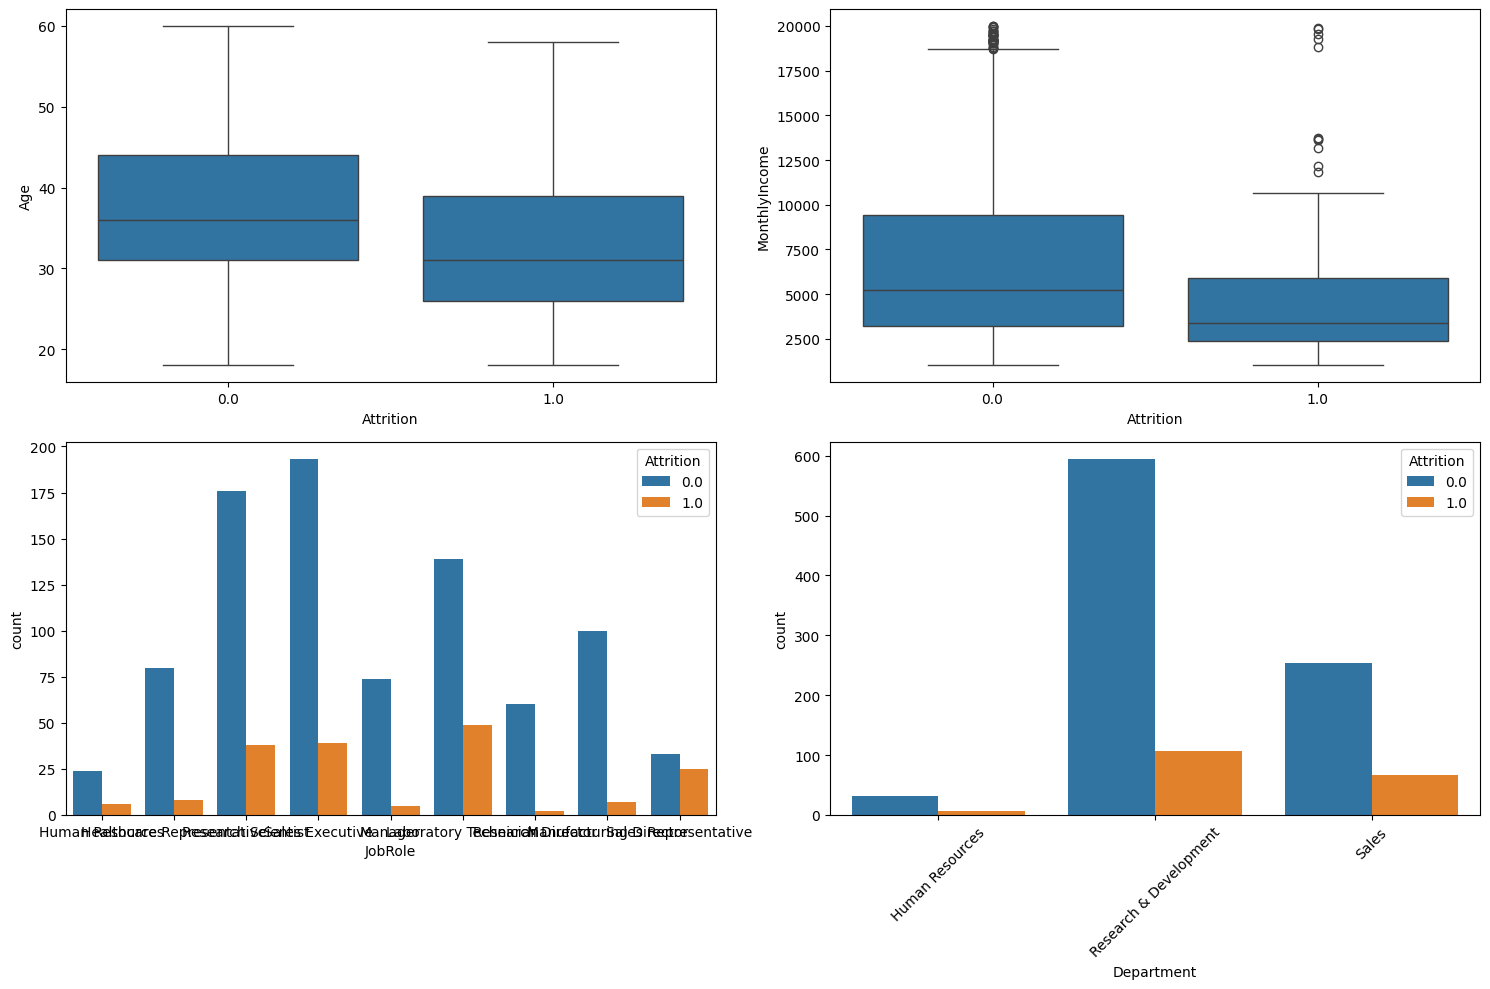

In [6]:
#Visualisasi attrition berdasarkan faktor-faktor penting
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=df, x='Attrition', y='Age', ax=axes[0,0])
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0,1])
sns.countplot(data=df, x='JobRole', hue='Attrition', ax=axes[1,0])
sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[1,1])
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [7]:
attrition_rate = df['Attrition'].mean() * 100
attrition_non_null = df['Attrition'].count()
attrition_null = df['Attrition'].isnull().sum()
print(f"Jumlah Data Valid: {attrition_non_null}")
#print(f"Jumlah Attrition Null: {attrition_null}")
print(f"Attrition Rate: {attrition_rate:.2f}%")
#df.head()

Jumlah Data Valid: 1058
Attrition Rate: 16.92%


## Data Preparation / Preprocessing

In [8]:
#remove irrelevant Col
cols_to_drop = ['EmployeeCount', 'EmployeeId','Over18', 'StandardHours']
df.drop(cols_to_drop, axis=1, inplace=True)
#df.head()

In [9]:
#Cleaning Attrition null
df = df.dropna(subset=['Attrition'])
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64


In [10]:
#label encode target
le_target = LabelEncoder()
df['Attrition'] = le_target.fit_transform(df['Attrition'])

In [11]:
def encode_dataset(df):
    """
    Encode dataset:
    - Object columns -> categorical (LabelEncoder)
    - Ordinal columns -> mapped to numeric
    - Keep numerical columns as-is
    Returns:
    - df_encoded: dataframe all numeric
    - numerical_cols: list of numeric columns
    - categorical_cols: list of categorical columns
    """
    le_dict = {}

    # Pisahkan sesuai tipe
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    # Encode the other categorical columns
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"{col} encoded categorical col to numeric col")

    print("\nFinal numerical columns:", numerical_cols)
    print("Final categorical columns:", categorical_cols)

    return df, numerical_cols, categorical_cols, le_dict

In [12]:
#encode num and cat col
df_encoded, numerical_cols, categorical_cols, le_dict = encode_dataset(df)

BusinessTravel encoded categorical col to numeric col
Department encoded categorical col to numeric col
EducationField encoded categorical col to numeric col
Gender encoded categorical col to numeric col
JobRole encoded categorical col to numeric col
MaritalStatus encoded categorical col to numeric col
OverTime encoded categorical col to numeric col

Final numerical columns: ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Final categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [13]:
df_encoded.info()
df_encoded.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1058 entries, 1 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1058 non-null   int64
 1   Attrition                 1058 non-null   int64
 2   BusinessTravel            1058 non-null   int64
 3   DailyRate                 1058 non-null   int64
 4   Department                1058 non-null   int64
 5   DistanceFromHome          1058 non-null   int64
 6   Education                 1058 non-null   int64
 7   EducationField            1058 non-null   int64
 8   EnvironmentSatisfaction   1058 non-null   int64
 9   Gender                    1058 non-null   int64
 10  HourlyRate                1058 non-null   int64
 11  JobInvolvement            1058 non-null   int64
 12  JobLevel                  1058 non-null   int64
 13  JobRole                   1058 non-null   int64
 14  JobSatisfaction           1058 non-null   int

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1,37,1,2,1141,1,11,2,3,1,0,...,3,1,0,15,2,1,1,0,0,0
2,51,1,2,1323,1,4,4,1,1,1,...,3,3,3,18,2,4,10,0,2,7
3,42,0,1,555,2,26,3,2,3,0,...,3,4,1,23,2,4,20,4,4,8
6,40,0,2,1124,2,1,2,3,2,1,...,4,3,3,6,2,2,4,3,0,2
7,55,1,2,725,1,2,3,3,4,1,...,3,4,1,24,2,3,5,2,1,4


In [14]:
#Split Dataset
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.68      0.73       173
           1       0.11      0.18      0.14        39

    accuracy                           0.59       212
   macro avg       0.45      0.43      0.43       212
weighted avg       0.66      0.59      0.62       212



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [17]:
#Tuning (HyperParameter) karena imbalance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

model_best = grid.best_estimator_
print("Best params:", grid.best_params_)


Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


## Evaluation

In [18]:
#evaluiation
y_pred_best = model_best.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Accuracy: 0.8584905660377359

Classification Report:
               precision    recall  f1-score   support

          No       0.85      1.00      0.92       173
         Yes       1.00      0.23      0.38        39

    accuracy                           0.86       212
   macro avg       0.93      0.62      0.65       212
weighted avg       0.88      0.86      0.82       212

Confusion Matrix:
 [[173   0]
 [ 30   9]]


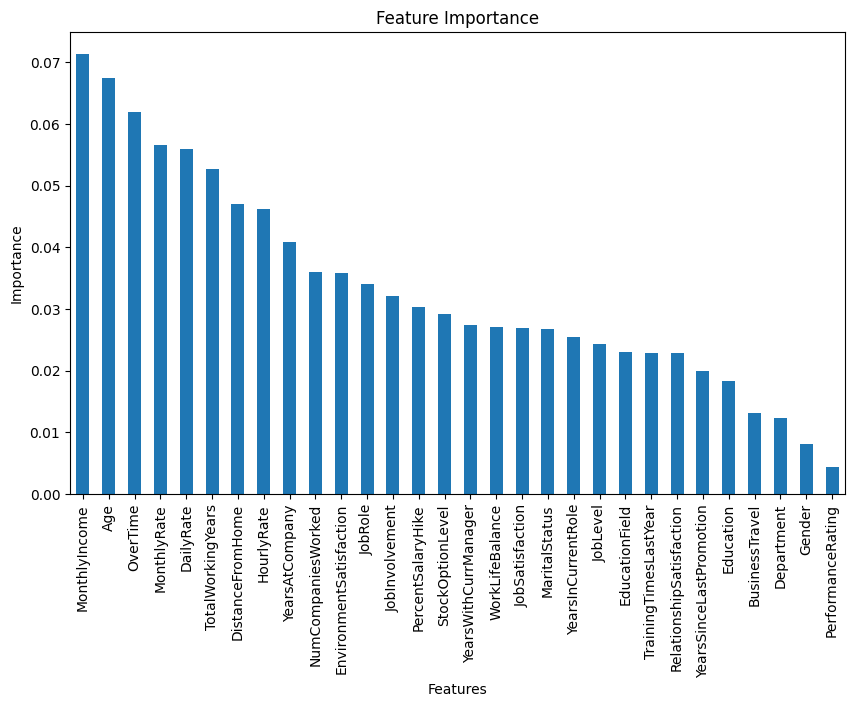

In [19]:
#fitur penting
feature_imp = pd.Series(model_best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feature_imp.plot(kind='bar')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [20]:
#save model dan scaler

joblib.dump(model_best, 'model_employee.pkl')
joblib.dump(scaler, 'scaler_employee.pkl')

joblib.dump(le_target, 'label_encoder_target.pkl')
joblib.dump(le_dict, 'label_encoder_employee.pkl')

joblib.dump(numerical_cols, 'numerical_cols_employee.pkl')
joblib.dump(categorical_cols, 'categorical_cols_employee.pkl')

print("Model dan Scaler berhasil disimpan")

Model dan Scaler berhasil disimpan
